In [16]:
import pandas as pd

df = pd.read_csv('/content/IMDB Dataset.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [8]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Ensure sentiment column is correctly mapped and handled
# Convert to string to avoid potential issues with mixed types, then map
df['sentiment'] = df['sentiment'].astype(str).map({'positive': 1, 'negative': 0})

# Drop rows where sentiment might still be NaN after mapping (e.g., if there were other values than 'positive'/'negative')
df.dropna(subset=['sentiment'], inplace=True)

# Convert sentiment to integer type as it's now 0 or 1
df['sentiment'] = df['sentiment'].astype(int)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word not in string.punctuation]
    return ' '.join(tokens)

df['processed_review'] = df['cleaned_review'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(df['processed_review'], df['sentiment'], test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np # Import numpy for boolean array conversion

# Filter out NaN values from y_train and corresponding X_train_tfidf
nan_indices_train = y_train.isnull()
y_train_filtered = y_train[~nan_indices_train]
X_train_tfidf_filtered = X_train_tfidf[~nan_indices_train.values]

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf_filtered, y_train_filtered)

# Filter out NaN values from y_test and corresponding X_test_tfidf for consistent evaluation
nan_indices_test = y_test.isnull()
y_test_filtered = y_test[~nan_indices_test]
X_test_tfidf_filtered = X_test_tfidf[~nan_indices_test.values]

y_pred_lr = lr_model.predict(X_test_tfidf_filtered)
lr_accuracy = accuracy_score(y_test_filtered, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(classification_report(y_test_filtered, y_pred_lr))

Logistic Regression Accuracy: 0.8854
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [22]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8489
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



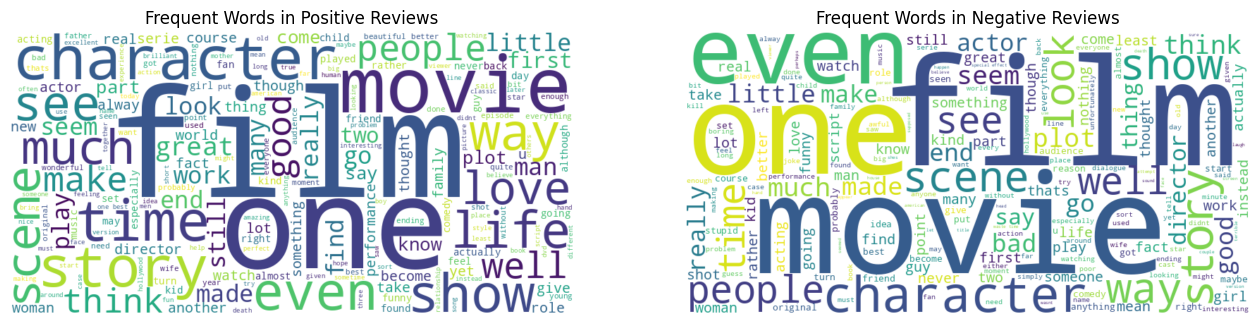

In [23]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

positive_reviews = ' '.join(df[df['sentiment'] == 1]['processed_review'])
negative_reviews = ' '.join(df[df['sentiment'] == 0]['processed_review'])

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Frequent Words in Positive Reviews')
axes[0].axis('off')

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Frequent Words in Negative Reviews')
axes[1].axis('off')
plt.show()

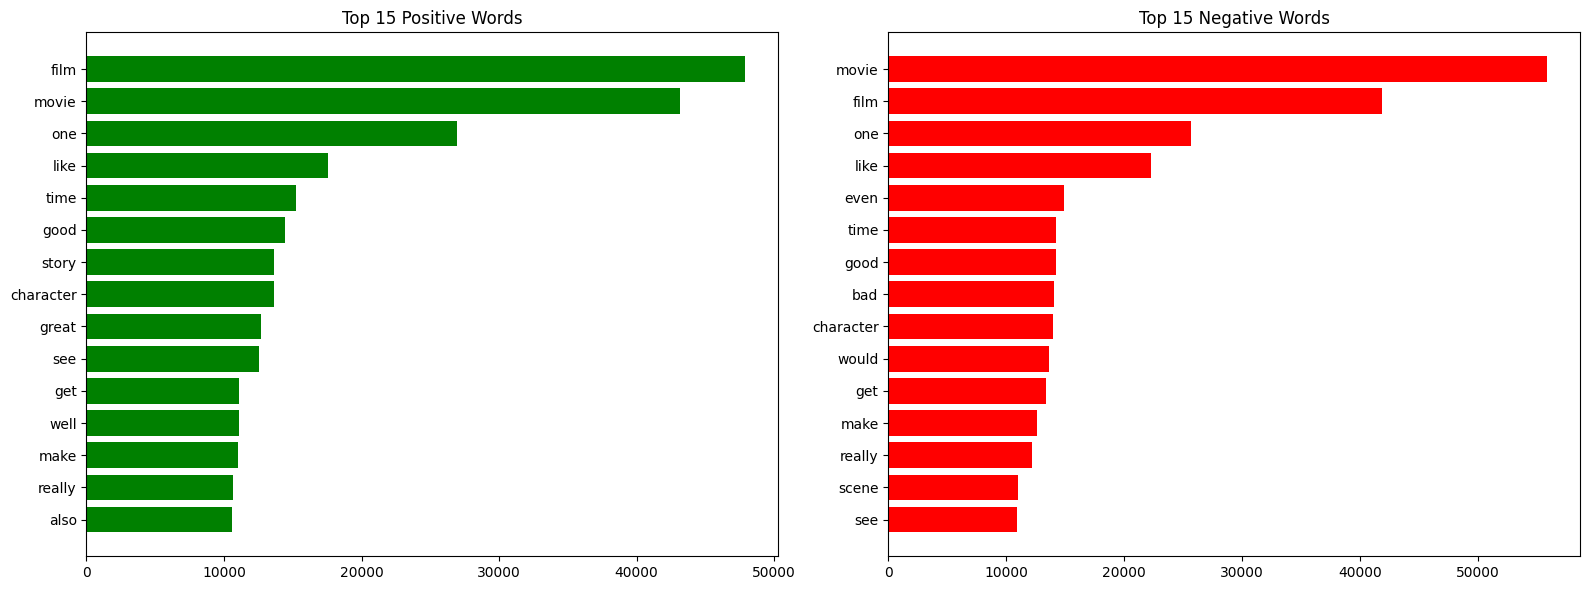


✅ Task 1 - Sentiment Analysis Completed!


In [24]:
import seaborn as sns

positive_words = positive_reviews.split()
negative_words = negative_reviews.split()

positive_freq = Counter(positive_words).most_common(15)
negative_freq = Counter(negative_words).most_common(15)

pos_words, pos_counts = zip(*positive_freq)
neg_words, neg_counts = zip(*negative_freq)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(pos_words, pos_counts, color='green')
axes[0].set_title('Top 15 Positive Words')
axes[0].invert_yaxis()

axes[1].barh(neg_words, neg_counts, color='red')
axes[1].set_title('Top 15 Negative Words')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✅ Task 1 - Sentiment Analysis Completed!")